# This notebook produces plots of the galaxy power spectrum

It shows how the observed power spectrum can be thought as a result of all the observational and physical effects that affect the mattter power spectrum. Biasing and window convolution are arbitrarily assumed. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from astropy import constants as const
c = const.c.value

In [3]:
# Set plotting and printing
import seaborn as sns
sns.set_style("whitegrid")
    
plt.rcParams['lines.solid_capstyle'] = 'round'
plt.rcParams['lines.dash_capstyle'] = 'round'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
font = {'size':18, 'family':'STIXGeneral'}
axislabelfontsize = 'x-large'
plt.rc('font', **font)
plt.rcParams['text.usetex'] = True

In [4]:
from pbjcosmo.PBJ import Pbj 
from pbjcosmo.tools import cosmology
import pbjcosmo.tools.param_handler as parhandler

[WARNING]: evogrowth for non LCDM growth functions not installed


In [6]:
# Load the parameter file and initialise a Pbj object
init_config = parhandler.read_file("/home/cosmologi/fmontano/Plot4TalkCollection/param_wide-angle.yaml")
theoryobject = Pbj(init_config)

# Compute the multipoles of the power spectrum

# Set a k-grid on which the model will be evaluated
# kf = 2*np.pi/7000
# KVALS = np.arange(1,600)*kf
KVALS = np.geomspace(0.1e-6,10,3000)

[info] The linear power spectrum will be computed with bacco
[info] Infrared resummation: True, kind: EH
[info] Alcock-Paczynski distortions: False
[info] Window convolution: all


  0% (0 of 1658880) |                    | Elapsed Time: 0:00:00 ETA:  --:--:--
  2% (49152 of 1658880) |                | Elapsed Time: 0:00:00 ETA:   0:00:02
  6% (106496 of 1658880) |               | Elapsed Time: 0:00:00 ETA:   0:00:01
 12% (212992 of 1658880) |#              | Elapsed Time: 0:00:00 ETA:   0:00:01
 25% (425984 of 1658880) |###            | Elapsed Time: 0:00:00 ETA:   0:00:00
 53% (884736 of 1658880) |########       | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (1658880 of 1658880) |##############| Elapsed Time: 0:00:00 Time:  0:00:00


  0% (0 of 1658880) |                    | Elapsed Time: 0:00:00 ETA:  --:--:--
  2% (49152 of 1658880) |                | Elapsed Time: 0:00:00 ETA:   0:00:01
  5% (90112 of 1658880) |                | Elapsed Time: 0:00:00 ETA:   0:00:01
 11% (196608 of 1658880) |#              | Elapsed Time: 0:00:00 ETA:   0:00:01
 21% (360448 of 1658880) |###            | Elapsed Time: 0:00:00 ETA:   0:00:00
 43% (720896 of 1658880) |######         | Elapsed Time: 0:00:00 ETA:   0:00:00
 88% (1474560 of 1658880) |############  | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (1658880 of 1658880) |##############| Elapsed Time: 0:00:00 Time:  0:00:00


  0% (0 of 2304000) |                    | Elapsed Time: 0:00:00 ETA:  --:--:--
  1% (32768 of 2304000) |                | Elapsed Time: 0:00:00 ETA:   0:00:04
  5% (122880 of 2304000) |               | Elapsed Time: 0:00:00 ETA:   0:00:02
 10% (237568 of 2304000) |#              | Elapsed Time: 0:00:00 ETA:   0:00:01
 19% (442368 of 2304000) |##             | Elapsed Time: 0:00:00 ETA:   0:00:00
 39% (909312 of 2304000) |#####          | Elapsed Time: 0:00:00 ETA:   0:00:00
 78% (1810432 of 2304000) |###########   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (2304000 of 2304000) |##############| Elapsed Time: 0:00:00 Time:  0:00:00
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [7]:
theoryobject.initialise_grid()

[info] Boxsize: 1500.0, grid properties: {'dk': 1, 'cf': 1, 'nbinsP': 128, 'nbinsB': 29}
[info] Using binning from window.
[info] k'_max for convolution:  0.638 h/Mpc.
[WARNING] Array of k' of the mixing matrix (for multipole 0) cut at k'=10^(-4) h/Mc
[WARNING] Array of k' of the mixing matrix (for multipole 1) cut at k'=10^(-4) h/Mc
[WARNING] Array of k' of the mixing matrix (for multipole 2) cut at k'=10^(-4) h/Mc
[WARNING] Array of k' of the mixing matrix (for multipole 3) cut at k'=10^(-4) h/Mc
[WARNING] Array of k' of the mixing matrix (for multipole 4) cut at k'=10^(-4) h/Mc
[info] Loaded window mixing matrix.
WARNING CHANGE THIS IN THE FUTURE 30 (500,)


In [8]:
if not theoryobject.do_redshift_rescaling:
    raise ValueError

In [9]:
BGS_biases_CROSSbright_mc19 = {
    "z": [0.142, 0.321, 0.142],
    "ng": [0.00889687805, 6.341683e-05, 0.00883846527],
    "Q": [1.4809, 4.7101, 1.4843],
    "E": [-1.309, -3.688, -1.3118],
    "b": [1.1994, 2.3148, 1.2001]
}

BGS_biases_CROSSfaint_mc20_175_ms19 = {
    "z": [0.142, 0.321, 0.142],
    "ng": [0.02150212713, 0.0021481321, 0.0214467519],
    "Q": [0.5832, 2.1922, 0.5856],
    "E": [-0.587, -2.0016, -0.5892],
    "b": [1.0925, 1.4252, 1.0925]
}

## 1. Linear matter power spectrum

In [10]:
# plt.plot(theoryobject.kL,theoryobject.PL)
# plt.xscale('log')
# plt.yscale('log')

#sistema redshift rescaling
P_MATTER = {
    'kh': theoryobject.kL,
    'P0': theoryobject.PL,
    'P2': np.zeros_like(theoryobject.kL),
    'P4': np.zeros_like(theoryobject.kL)
}

## 2. Kaiser power spectrum

In [11]:
dict_sample1 = BGS_biases_CROSSbright_mc19
dict_sample2 = BGS_biases_CROSSfaint_mc20_175_ms19
INDEX_Z = 2 #0: 0.1-0.3 / 1: 0.3-0.5 / 2:0.1-0.5

ZETA = dict_sample1['z'][INDEX_Z]
# PSN = 1/(dict_sample1['ng'][INDEX_Z])
PSN = 0
print(ZETA)

0.142


In [12]:
P_kaiser_wa = theoryobject.theory_inst.P_kaiser_wa(
    ZETA, theoryobject.do_redshift_rescaling, theoryobject.PL, cosmo=theoryobject.Inputcosmo,
    kgrid = KVALS,
    b1X=dict_sample1['b'][INDEX_Z], b1Y=dict_sample2['b'][INDEX_Z],
    Psn=PSN)

print(np.shape(P_kaiser_wa))
P_BIAS = {
    'kh': theoryobject.kL,
    'P0': dict_sample1['b'][INDEX_Z]*dict_sample2['b'][INDEX_Z]*theoryobject.PL,
    'P2': np.zeros_like(theoryobject.kL),
    'P4': np.zeros_like(theoryobject.kL)
}
P_KASIER = {
    'kh': KVALS,
    'P0': P_kaiser_wa[0,0],
    'P1': np.imag(P_kaiser_wa[0,1]),
    'P2': P_kaiser_wa[0,2],
    'P3': np.imag(P_kaiser_wa[0,3]),
    'P4': P_kaiser_wa[0,4]
}
r = cosmology.radial_comoving_distance(ZETA, theoryobject.Inputcosmo["Om"], theoryobject.Inputcosmo["w0"], theoryobject.Inputcosmo["wa"])/theoryobject.Inputcosmo["h"] #in Mpc
P_KASIER_WA = {
    'kh': KVALS,
    'P0': P_kaiser_wa[0,0]+P_kaiser_wa[1,0]/(r*KVALS)+P_kaiser_wa[2,0]/(r*KVALS)**2,
    'P1': np.imag(P_kaiser_wa[0,1]+P_kaiser_wa[1,1]/(r*KVALS)+P_kaiser_wa[2,1]/(r*KVALS)**2),
    'P2': P_kaiser_wa[0,2]+P_kaiser_wa[1,2]/(r*KVALS)+P_kaiser_wa[2,2]/(r*KVALS)**2,
    'P3': np.imag(P_kaiser_wa[0,3]+P_kaiser_wa[1,3]/(r*KVALS)+P_kaiser_wa[2,3]/(r*KVALS)**2),
    'P4': P_kaiser_wa[0,4]+P_kaiser_wa[1,4]/(r*KVALS)+P_kaiser_wa[2,4]/(r*KVALS)**2,
    'P0_n1': P_kaiser_wa[0,0]+P_kaiser_wa[1,0]/(r*KVALS),
    'P1_n1': np.imag(P_kaiser_wa[0,1]+P_kaiser_wa[1,1]/(r*KVALS)),
    'P2_n1': P_kaiser_wa[0,2]+P_kaiser_wa[1,2]/(r*KVALS),
    'P3_n1': np.imag(P_kaiser_wa[0,3]+P_kaiser_wa[1,3]/(r*KVALS)),
    'P4_n1': P_kaiser_wa[0,4]+P_kaiser_wa[1,4]/(r*KVALS)
}

(3, 5, 3000)


## Doppler power spectrum

In [13]:
P_kaiser_doppler_wa = theoryobject.theory_inst.P_kaiser_doppler_wa(
    ZETA, theoryobject.do_redshift_rescaling, theoryobject.PL, theoryobject.Inputcosmo,
    kgrid = KVALS,
    b1X=dict_sample1['b'][INDEX_Z], b1Y=dict_sample2['b'][INDEX_Z], 
    bQX=dict_sample1['Q'][INDEX_Z], bQY=dict_sample2['Q'][INDEX_Z],
    bEX=dict_sample1['E'][INDEX_Z], bEY=dict_sample2['E'][INDEX_Z],
    Psn=PSN)

print(np.shape(P_kaiser_doppler_wa))
P_DOPP = {
    'kh': KVALS,
    'P0': P_kaiser_doppler_wa[0,0],
    'P1': np.imag(P_kaiser_doppler_wa[0,1]),
    'P2': P_kaiser_doppler_wa[0,2],
    'P3': np.imag(P_kaiser_doppler_wa[0,3]),
    'P4': P_kaiser_doppler_wa[0,4]
}

P_DOPP_WA = {
    'kh': KVALS,
    'P0': P_kaiser_doppler_wa[0,0]+P_kaiser_doppler_wa[1,0]/(r*KVALS)+P_kaiser_doppler_wa[2,0]/(r*KVALS)**2,
    'P1': np.imag(P_kaiser_doppler_wa[0,1]+P_kaiser_doppler_wa[1,1]/(r*KVALS)+P_kaiser_doppler_wa[2,1]/(r*KVALS)**2),
    'P2': P_kaiser_doppler_wa[0,2]+P_kaiser_doppler_wa[1,2]/(r*KVALS)+P_kaiser_doppler_wa[2,2]/(r*KVALS)**2,
    'P3': np.imag(P_kaiser_doppler_wa[0,3]+P_kaiser_doppler_wa[1,3]/(r*KVALS)+P_kaiser_doppler_wa[2,3]/(r*KVALS)**2),
    'P4': P_kaiser_doppler_wa[0,4]+P_kaiser_doppler_wa[1,4]/(r*KVALS)+P_kaiser_doppler_wa[2,4]/(r*KVALS)**2,
    'P0_n1': P_kaiser_doppler_wa[0,0]+P_kaiser_doppler_wa[1,0]/(r*KVALS),
    'P1_n1': np.imag(P_kaiser_doppler_wa[0,1]+P_kaiser_doppler_wa[1,1]/(r*KVALS)),
    'P2_n1': P_kaiser_doppler_wa[0,2]+P_kaiser_doppler_wa[1,2]/(r*KVALS),
    'P3_n1': np.imag(P_kaiser_doppler_wa[0,3]+P_kaiser_doppler_wa[1,3]/(r*KVALS)),
    'P4_n1': P_kaiser_doppler_wa[0,4]+P_kaiser_doppler_wa[1,4]/(r*KVALS)
}

(3, 5, 3000)


## Convolved power spectrum

In [14]:
P_kaiser_doppler_wa_conv = theoryobject.theory_inst.convolve_power_spectrum_wa(theoryobject.kpW[0], theoryobject.theory_inst.P_kaiser_doppler_wa, theoryobject.window,
                                                                    ZETA, False,
                                                                    plinear=theoryobject.PL,
                                                                    cosmo=theoryobject.Inputcosmo,
                                                                    b1X=dict_sample1['b'][INDEX_Z], b1Y=dict_sample2['b'][INDEX_Z], 
                                                                    bQX=dict_sample1['Q'][INDEX_Z], bQY=dict_sample2['Q'][INDEX_Z],
                                                                    bEX=dict_sample1['E'][INDEX_Z], bEY=dict_sample2['E'][INDEX_Z],
                                                                    Psn=PSN)

print(np.shape(P_kaiser_doppler_wa_conv))
P_ALL_CONV = {
    'kh': theoryobject.w_dict['k1'],
    'P0': P_kaiser_doppler_wa_conv[0],
    'P1': np.imag(P_kaiser_doppler_wa_conv[1]),
    'P2': P_kaiser_doppler_wa_conv[2],
    'P3': np.imag(P_kaiser_doppler_wa_conv[3]),
    'P4': P_kaiser_doppler_wa_conv[4]
}

(5, 300)


# Plots

/home/cosmologi/miniconda3/envs/pbjenv/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/cosmologi/miniconda3/envs/pbjenv/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(0.0, 450.0)

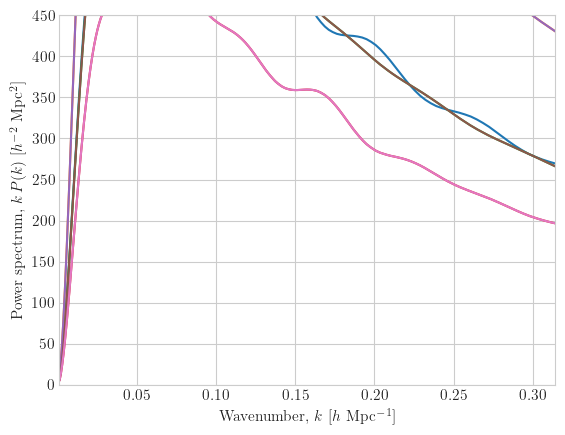

In [31]:
k_min, k_max = np.min(P_ALL_CONV['kh']), np.max(P_ALL_CONV['kh'])

plt.plot(P_MATTER['kh'],P_MATTER['P0']*P_MATTER['kh'])

plt.plot(P_KASIER['kh'],P_KASIER['P0']*P_KASIER['kh'])
plt.plot(P_KASIER['kh'],P_KASIER['P2']*P_KASIER['kh'])
plt.plot(P_KASIER['kh'],P_KASIER['P4']*P_KASIER['kh']*10)

plt.plot(P_DOPP['kh'],P_DOPP['P0']*P_DOPP['kh'])
plt.plot(P_DOPP['kh'],P_DOPP['P2']*P_DOPP['kh'])
plt.plot(P_DOPP['kh'],P_DOPP['P4']*P_DOPP['kh']*10)

plt.xlabel(r'Wavenumber, $k$ [$h$ Mpc$^{-1}$]')
plt.ylabel(r'Power spectrum, $k\,P(k)$ [$h^{-2}$ Mpc$^2$]')
plt.xlim(k_min,k_max)
plt.ylim(0,450)
# plt.ylim(-100,100)

(-70.0, 50.0)

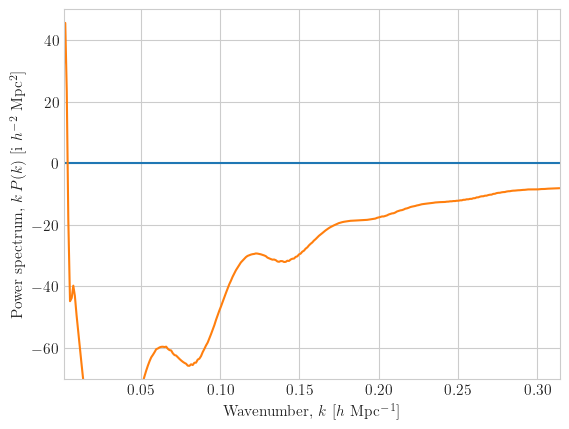

In [30]:
k_min, k_max = np.min(P_ALL_CONV['kh']), np.max(P_ALL_CONV['kh'])

plt.plot(P_MATTER['kh'],np.zeros_like(P_MATTER['kh']))

# plt.plot(P_DOPP['kh'],P_DOPP['P1']*P_DOPP['kh'])
# plt.plot(P_DOPP['kh'],P_DOPP['P3']*P_DOPP['kh'])

# plt.plot(P_KASIER_WA['kh'],P_KASIER_WA['P1']*P_KASIER_WA['kh'])
# plt.plot(P_KASIER_WA['kh'],P_KASIER_WA['P3']*P_KASIER_WA['kh'])

plt.plot(P_ALL_CONV['kh'],P_ALL_CONV['P1']*P_ALL_CONV['kh'])
# plt.plot(P_ALL_CONV['kh'],P_ALL_CONV['P3']*P_ALL_CONV['kh'])

plt.xlabel(r'Wavenumber, $k$ [$h$ Mpc$^{-1}$]')
plt.ylabel(r'Power spectrum, $k\,P(k)$ [i $h^{-2}$ Mpc$^2$]')
plt.xlim(k_min,k_max)
# plt.ylim(0,450)
plt.ylim(-70,50)

/home/cosmologi/miniconda3/envs/pbjenv/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/cosmologi/miniconda3/envs/pbjenv/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_1429377/930458465.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


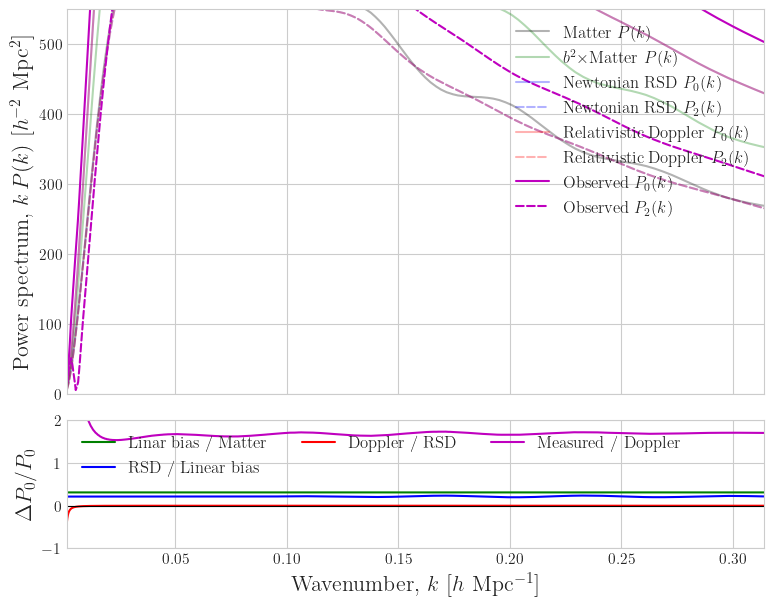

In [29]:
# --- Parametri e griglia comune in k ---
k_min, k_max = np.min(P_ALL_CONV['kh']), np.max(P_ALL_CONV['kh'])
N_k_common = 20001
k_common = np.linspace(k_min, k_max, N_k_common)

# --- funzione di utilità: assicura array ordinati e usa np.interp ---
def interp_on_common(k_src, y_src, k_target):
    order = np.argsort(k_src)
    k_sorted = np.asarray(k_src)[order]
    y_sorted = np.asarray(y_src)[order]
    y_interp = np.interp(k_target, k_sorted, y_sorted,
                         left=y_sorted[0], right=y_sorted[-1])
    return y_interp

# --- Interpola tutti i modelli su k_common ---
models = {'MATTER': P_MATTER, 'KAISER': P_KASIER, 'DOPP': P_DOPP, 'CONV': P_ALL_CONV, 'BIAS': P_BIAS}
P_interp = {}
for name, M in models.items():
    P_interp[name] = {
        'kh': k_common,
        'P0': interp_on_common(M['kh'], M['P0'], k_common),
        'P2': interp_on_common(M['kh'], M['P2'], k_common),
        'P4': interp_on_common(M['kh'], M['P4'], k_common)
    }

# --- Crea figura: 2 pannelli (spettro e variazione P0) ---
fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1})

# --- Pannello superiore: k * P_l(k) ---
axs[0].plot(P_interp['MATTER']['kh'], P_interp['MATTER']['P0'] * P_interp['MATTER']['kh'],
            color='k', label=r'Matter $P(k)$',alpha=0.3)

axs[0].plot(P_interp['BIAS']['kh'], P_interp['BIAS']['P0'] * P_interp['BIAS']['kh'],
            color='g', label=r'$b^2\times$Matter $P(k)$',alpha=0.3)

axs[0].plot(P_interp['KAISER']['kh'], P_interp['KAISER']['P0'] * P_interp['KAISER']['kh'],
            color='b', label=r'Newtonian RSD $P_0(k)$',alpha=0.3)
axs[0].plot(P_interp['KAISER']['kh'], P_interp['KAISER']['P2'] * P_interp['KAISER']['kh'],
            color='b', linestyle='--', label=r'Newtonian RSD $P_2(k)$',alpha=0.3)

axs[0].plot(P_interp['DOPP']['kh'], P_interp['DOPP']['P0'] * P_interp['DOPP']['kh'],
            color='r', label=r'Relativistic Doppler $P_0(k)$',alpha=0.3)
axs[0].plot(P_interp['DOPP']['kh'], P_interp['DOPP']['P2'] * P_interp['DOPP']['kh'],
            color='r', linestyle='--', label=r'Relativistic Doppler $P_2(k)$',alpha=0.3)

axs[0].plot(P_interp['CONV']['kh'], P_interp['CONV']['P0'] * P_interp['CONV']['kh'],
            color='m', label=r'Observed $P_0(k)$')
axs[0].plot(P_interp['CONV']['kh'], P_interp['CONV']['P2'] * P_interp['CONV']['kh'],
            color='m', linestyle='--', label=r'Observed $P_2(k)$')

axs[0].set_ylabel(r'Power spectrum, $k\,P(k)$ [$h^{-2}$ Mpc$^2$]',fontsize=16)
axs[0].set_xlim(k_min, k_max)
axs[0].set_ylim(0, 550)
axs[0].legend(fontsize=12,framealpha=0,ncols=1,loc='upper right')
# axs[0].set_title("Power spectra and variation of monopole $P_0$")

# --- Funzione per differenze relative sicure ---
def rel_diff_safe(new, old):
    old = np.asarray(old)
    new = np.asarray(new)
    with np.errstate(divide='ignore', invalid='ignore'):
        diff = (new - old) / old
        diff = np.where(np.isfinite(diff), diff, np.nan)
    return diff

# --- Pannello inferiore: variazione relativa di P0 ---
ell = 'P0'
old0 = P_interp['MATTER'][ell]
new0 = P_interp['BIAS'][ell]
y0 = rel_diff_safe(new0, old0)

old = P_interp['BIAS'][ell]
new = P_interp['KAISER'][ell]
y1 = rel_diff_safe(new, old)

old2 = P_interp['KAISER'][ell]
new2 = P_interp['DOPP'][ell]
y2 = rel_diff_safe(new2, old2)

old3 = P_interp['DOPP'][ell]
new3 = P_interp['CONV'][ell]
y3 = rel_diff_safe(new3, old3)

axs[1].plot(k_common, y0, color='g', label=r'Linar bias / Matter')
axs[1].plot(k_common, y1, color='b', label=r'RSD / Linear bias')
axs[1].plot(k_common, y2*10, color='r', label=r'Doppler / RSD')
axs[1].plot(k_common, y3*10, color='m', label=r'Measured / Doppler')
axs[1].axhline(0, color='k', lw=0.8)
axs[1].set_ylabel(r'$\Delta P_0 / P_0$',fontsize=16)
axs[1].set_xlabel(r'Wavenumber, $k$ [$h$ Mpc$^{-1}$]',fontsize=16)
# axs[1].set_ylim(-0.2, 1.2)
axs[1].set_ylim(-1, 2)
axs[1].legend(fontsize=12,framealpha=0,ncols=3,loc='upper left')

plt.tight_layout()
# plt.savefig("EvenPk_cross_0.pdf",format="pdf",bbox_inches='tight')
plt.show()


/tmp/ipykernel_1429377/1382545006.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


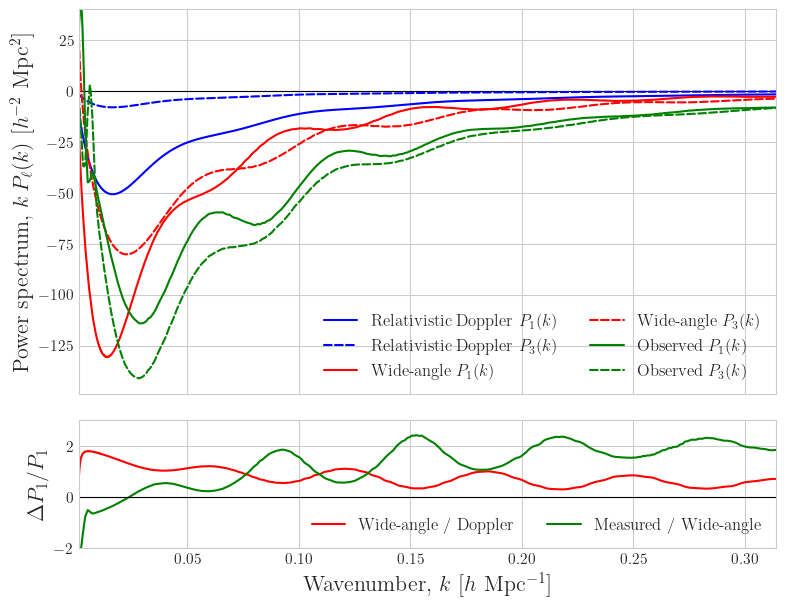

In [ ]:
# --- Parametri e griglia comune in k ---
k_min, k_max = np.min(P_ALL_CONV['kh']), np.max(P_ALL_CONV['kh'])
N_k_common = 2000
k_common = np.linspace(k_min, k_max, N_k_common)

# --- funzione di utilità: assicura array ordinati e usa np.interp ---
def interp_on_common(k_src, y_src, k_target):
    order = np.argsort(k_src)
    k_sorted = np.asarray(k_src)[order]
    y_sorted = np.asarray(y_src)[order]
    y_interp = np.interp(k_target, k_sorted, y_sorted,
                         left=y_sorted[0], right=y_sorted[-1])
    return y_interp

# --- Interpola tutti i modelli su k_common ---
models = {'DOPP': P_DOPP, 'DOPP_WA': P_DOPP_WA, 'CONV': P_ALL_CONV}
P_interp = {}
for name, M in models.items():
    P_interp[name] = {
        'kh': k_common,
        'P1': interp_on_common(M['kh'], M['P1'], k_common),
        'P3': interp_on_common(M['kh'], M['P3'], k_common)
    }

# --- Crea figura: 2 pannelli (spettro e variazione P0) ---
fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1})

# --- Pannello superiore: k * P_l(k) ---
axs[0].axhline(0, color='k', lw=0.8)

axs[0].plot(P_interp['DOPP']['kh'], P_interp['DOPP']['P1'] * P_interp['DOPP']['kh'],
            color='b', label=r'Relativistic Doppler $P_1(k)$',alpha=1)
axs[0].plot(P_interp['DOPP']['kh'], P_interp['DOPP']['P3'] * P_interp['DOPP']['kh'],
            color='b', linestyle='--', label=r'Relativistic Doppler $P_3(k)$',alpha=1)

axs[0].plot(P_interp['DOPP_WA']['kh'], P_interp['DOPP_WA']['P1'] * P_interp['DOPP_WA']['kh'],
            color='r', label=r'Wide-angle $P_1(k)$',alpha=1)
axs[0].plot(P_interp['DOPP_WA']['kh'], P_interp['DOPP_WA']['P3'] * P_interp['DOPP_WA']['kh'],
            color='r', linestyle='--', label=r'Wide-angle $P_3(k)$',alpha=1)

axs[0].plot(P_interp['CONV']['kh'], P_interp['CONV']['P1'] * P_interp['CONV']['kh'],
            color='g', label=r'Observed $P_1(k)$')
axs[0].plot(P_interp['CONV']['kh'], P_interp['CONV']['P3'] * P_interp['CONV']['kh'],
            color='g', linestyle='--', label=r'Observed $P_3(k)$')


axs[0].set_ylabel(r'Power spectrum, $k\,P_\ell(k)$ [$h^{-2}$ Mpc$^2$]',fontsize=16)
axs[0].set_xlim(k_min, k_max)
axs[0].set_ylim(-149, 40)
axs[0].legend(fontsize=12, ncol=2, loc='lower right',framealpha=0)

# --- Funzione per differenze relative sicure ---
def rel_diff_safe(new, old):
    old = np.asarray(old)
    new = np.asarray(new)
    with np.errstate(divide='ignore', invalid='ignore'):
        diff = (new - old) / old
        diff = np.where(np.isfinite(diff), diff, np.nan)
    return diff

# --- Pannello inferiore: variazione relativa di P0 ---
ell = 'P1'
old = P_interp['DOPP'][ell]
new = P_interp['DOPP_WA'][ell]
y1 = rel_diff_safe(new, old)

old2 = P_interp['DOPP_WA'][ell]
new2 = P_interp['CONV'][ell]
y2 = rel_diff_safe(new2, old2)

axs[1].plot(k_common, y1, color='r', label=r'Wide-angle / Doppler')
axs[1].plot(k_common, y2, color='g', label=r'Measured / Wide-angle')
axs[1].axhline(0, color='k', lw=0.8)
axs[1].set_ylabel(r'$\Delta P_1 / P_1$',fontsize=16)
axs[1].set_xlabel(r'Wavenumber, $k$ [$h$ Mpc$^{-1}$]',fontsize=16)
axs[1].set_ylim(-2, 3)
axs[1].legend(fontsize=12,loc='lower right',framealpha=0,ncols=2)

plt.tight_layout()
plt.savefig("./obsPk_plots/OddPk_cross.pdf",format="pdf",bbox_inches='tight')
# plt.savefig("OddPk_cross.png",format="png",dpi=600,bbox_inches='tight')
plt.show()


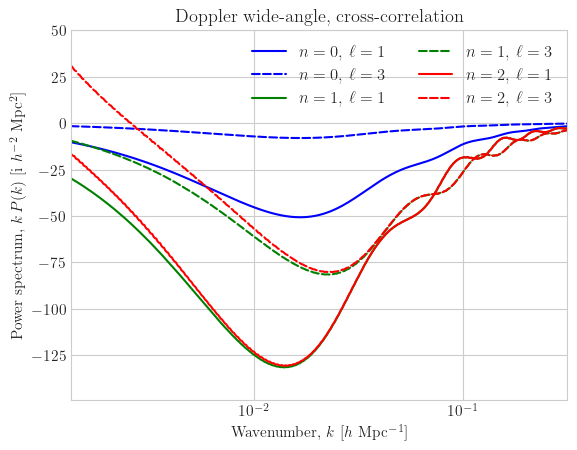

In [27]:
k_min, k_max = np.min(P_ALL_CONV['kh']), np.max(P_ALL_CONV['kh'])

PLOT_MODEL = P_DOPP
PLOT_MODEL_WA = P_DOPP_WA

plt.plot(PLOT_MODEL['kh'],PLOT_MODEL['P1']*PLOT_MODEL['kh'],label=r'$n=0,\,\ell=1$',color='b',ls='-')
plt.plot(PLOT_MODEL['kh'],PLOT_MODEL['P3']*PLOT_MODEL['kh'],label=r'$n=0,\,\ell=3$',color='b',ls='--')

plt.plot(PLOT_MODEL_WA['kh'],PLOT_MODEL_WA['P1_n1']*PLOT_MODEL_WA['kh'],label=r'$n=1,\,\ell=1$',color='g',ls='-')
plt.plot(PLOT_MODEL_WA['kh'],PLOT_MODEL_WA['P3_n1']*PLOT_MODEL_WA['kh'],label=r'$n=1,\,\ell=3$',color='g',ls='--')

plt.plot(PLOT_MODEL_WA['kh'],PLOT_MODEL_WA['P1']*PLOT_MODEL_WA['kh'],label=r'$n=2,\,\ell=1$',color='r',ls='-')
plt.plot(PLOT_MODEL_WA['kh'],PLOT_MODEL_WA['P3']*PLOT_MODEL_WA['kh'],label=r'$n=2,\,\ell=3$',color='r',ls='--')

plt.title(r'Doppler wide-angle, cross-correlation')
plt.xlabel(r'Wavenumber, $k$ [$h$ Mpc$^{-1}$]')
plt.ylabel(r'Power spectrum, $k\,P(k)$ [i $h^{-2}$ Mpc$^2$]')
plt.xlim(k_min,k_max)
plt.legend(fontsize=12,loc='best',framealpha=0,ncols=2)
# plt.ylim(0,450)
plt.ylim(-149,50)
plt.xscale('log')

# plt.savefig("DWA-odd.png",format="png",dpi=600,bbox_inches='tight')


/home/cosmologi/miniconda3/envs/pbjenv/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/cosmologi/miniconda3/envs/pbjenv/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


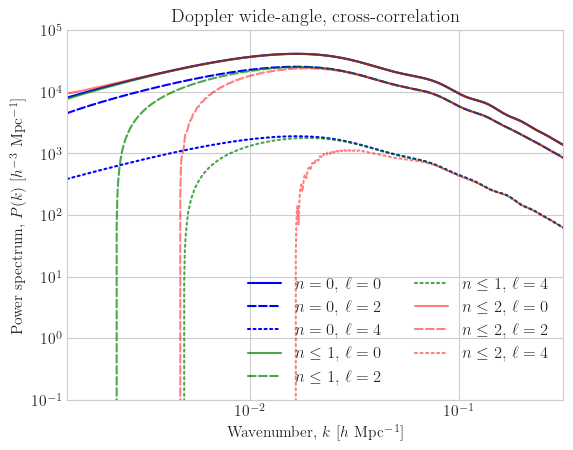

In [26]:
k_min, k_max = np.min(P_ALL_CONV['kh']), np.max(P_ALL_CONV['kh'])

PLOT_MODEL = P_DOPP
PLOT_MODEL_WA = P_DOPP_WA

plt.plot(PLOT_MODEL['kh'],PLOT_MODEL['P0'],label=r'$n=0,\,\ell=0$',color='b',ls='-')
plt.plot(PLOT_MODEL['kh'],PLOT_MODEL['P2'],label=r'$n=0,\,\ell=2$',color='b',ls='--')
plt.plot(PLOT_MODEL['kh'],PLOT_MODEL['P4'],label=r'$n=0,\,\ell=4$',color='b',ls=':')

plt.plot(PLOT_MODEL_WA['kh'],PLOT_MODEL_WA['P0_n1'],label=r'$n\le 1,\,\ell=0$',color='g',ls='-',alpha=0.7)
plt.plot(PLOT_MODEL_WA['kh'],PLOT_MODEL_WA['P2_n1'],label=r'$n\le 1,\,\ell=2$',color='g',ls='--',alpha=0.7)
plt.plot(PLOT_MODEL_WA['kh'],PLOT_MODEL_WA['P4_n1'],label=r'$n\le 1,\,\ell=4$',color='g',ls=':',alpha=0.7)

plt.plot(PLOT_MODEL_WA['kh'],PLOT_MODEL_WA['P0'],label=r'$n\le 2,\,\ell=0$',color='r',ls='-',alpha=0.5)
plt.plot(PLOT_MODEL_WA['kh'],PLOT_MODEL_WA['P2'],label=r'$n\le 2,\,\ell=2$',color='r',ls='--',alpha=0.5)
plt.plot(PLOT_MODEL_WA['kh'],PLOT_MODEL_WA['P4'],label=r'$n\le 2,\,\ell=4$',color='r',ls=':',alpha=0.5)

plt.title(r'Doppler wide-angle, cross-correlation')
plt.xlabel(r'Wavenumber, $k$ [$h$ Mpc$^{-1}$]')
plt.ylabel(r'Power spectrum, $P(k)$ [$h^{-3}$ Mpc$^{-1}$]')
plt.xlim(k_min,k_max)
plt.legend(fontsize=12,loc='best',framealpha=0,ncols=2)
# plt.ylim(0,450)
plt.ylim(0.1,1e5)
plt.yscale('log')
plt.xscale('log')

# plt.savefig("DWA_even.png",format="png",dpi=600,bbox_inches='tight')